# Reproduce CCD oil & gas charts from SSP output

Builds three figures from `decomposed_ssp_output.csv`:
1. Oil production (kb/d, bars) + flaring volumes (MMcfd, lines) BAU vs ZRF, 2015-2030
2. Flaring-related emissions (Mt CO2e) BAU vs ZRF + flaring intensity (m3/Bbl)
3. CH4 emissions from O&G operations 2024, stacked by emission type x facility (IEA shares)

Strategy mapping (set via `BAU_STRATEGY` / `ZRF_STRATEGY`):
- `0` BASE — calibrated BAU input (no transformations applied)
- `6003` historical BAU strategy id
- `6004` Unconditional NDC (typically ZRF target)
- `6005` Conditional NDC

In [65]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

RUN_DIR = Path('/Users/fabianfuentes/git/ssp_libya/ssp_modeling/ssp_run_output/sisepuede_results_sisepuede_run_2026-04-24T19;17;12.880619')
df = pd.read_csv(RUN_DIR / 'decomposed_ssp_output.csv')
att = pd.read_csv(RUN_DIR / 'ATTRIBUTE_PRIMARY.csv')
df = df.merge(att[['primary_id','strategy_id']], on='primary_id')
df['year'] = df['time_period'] + 2015
df = df[df.strategy_id != 0].copy()   # drop BASE: not used
print('strategies:', sorted(df.strategy_id.unique()))
print('years:', df.year.min(), '->', df.year.max())
df.shape

strategies: [np.int64(6003), np.int64(6004), np.int64(6005)]
years: 2023 -> 2050


(84, 4112)

In [66]:
# Strategy selection — adjust if BAU/ZRF correspond to different ids in this run
BAU_STRATEGY = 6003   # calibrated BAU (BASE / strategy 0 dropped, not used)
ZRF_STRATEGY = 6004   # Unconditional NDC (gas flaring recovery active)

# Unit conversions
GJ_PER_BBL = 6.119          # crude LHV
MJ_PER_M3_NG = 36.6
CF_PER_M3 = 35.3147
DAYS = 365.0
M3_PER_BBL = 0.159
GWP_CH4 = 28.0

def pj_to_kbd(pj):
    return pj * 1e6 / (DAYS * GJ_PER_BBL * 1e3)

def pj_to_m3_crude(pj):
    # 1 bbl = 6.119 GJ; 1 m3 = 1/0.159 bbl
    return pj * 1e9 / (GJ_PER_BBL * 1e9 / M3_PER_BBL) * 1e9   # PJ -> GJ then to m3

def pj_to_mmcfd_ng(pj):
    # PJ -> m3 (NG) -> cf -> per day in millions
    m3_yr = pj * 1e9 / MJ_PER_M3_NG
    cf_yr = m3_yr * CF_PER_M3
    return cf_yr / DAYS / 1e6

In [67]:
# Build per-strategy annual frame for the variables we need
FGTV_FLAR_CO2 = ['emission_co2e_co2_fgtv_flaring_fuel_crude', 'emission_co2e_co2_fgtv_flaring_fuel_natural_gas', 'emission_co2e_co2_fgtv_flaring_fuel_oil']
FGTV_FLAR_CH4 = ['emission_co2e_ch4_fgtv_flaring_fuel_crude', 'emission_co2e_ch4_fgtv_flaring_fuel_natural_gas', 'emission_co2e_ch4_fgtv_flaring_fuel_oil']
FGTV_VENT_CH4 = ['emission_co2e_ch4_fgtv_venting_fuel_crude', 'emission_co2e_ch4_fgtv_venting_fuel_natural_gas', 'emission_co2e_ch4_fgtv_venting_fuel_oil']
FGTV_DTP_CH4 = ['emission_co2e_ch4_fgtv_dtp_fuel_crude', 'emission_co2e_ch4_fgtv_dtp_fuel_natural_gas', 'emission_co2e_ch4_fgtv_dtp_fuel_oil']

keep = ['strategy_id', 'year', 'prod_enfu_fuel_crude_pj', 'prod_enfu_fuel_natural_gas_pj', 'ef_fgtv_production_flaring_tonne_co2_per_m3_fuel_crude', 'ef_fgtv_production_flaring_tonne_ch4_per_m3_fuel_crude'] + FGTV_FLAR_CO2 + FGTV_FLAR_CH4 + FGTV_VENT_CH4 + FGTV_DTP_CH4
keep = [c for c in keep if c and c.strip()]   # safety: drop any empty/whitespace entries
missing = [c for c in keep if c not in df.columns]
assert not missing, f'Missing columns: {missing}'

agg = df[keep].copy()
agg['flar_emis_mt_co2e'] = agg[FGTV_FLAR_CO2 + FGTV_FLAR_CH4].sum(axis=1)
agg['vent_ch4_mt_co2e'] = agg[FGTV_VENT_CH4].sum(axis=1)
agg['dtp_ch4_mt_co2e'] = agg[FGTV_DTP_CH4].sum(axis=1)

# Approximate flared NG volume from CO2 emissions: ~1.9 Mt CO2 per Bcm of NG combusted.
CO2_PER_BCM_FLARED = 1.9
agg['flared_bcm'] = agg[FGTV_FLAR_CO2].sum(axis=1) / CO2_PER_BCM_FLARED
agg['flared_mmcfd'] = agg['flared_bcm'] * 1e9 * CF_PER_M3 / DAYS / 1e6

agg['oil_kbd'] = pj_to_kbd(agg['prod_enfu_fuel_crude_pj'])
agg['flar_intensity_m3_per_bbl'] = (agg['flared_bcm'] * 1e9) / (agg['oil_kbd'] * 1e3 * DAYS)
agg.head()

,strategy_id,year,prod_enfu_fuel_crude_pj,prod_enfu_fuel_natural_gas_pj,ef_fgtv_production_flaring_tonne_co2_per_m3_fuel_crude,ef_fgtv_production_flaring_tonne_ch4_per_m3_fuel_crude,emission_co2e_co2_fgtv_flaring_fuel_crude,emission_co2e_co2_fgtv_flaring_fuel_natural_gas,emission_co2e_co2_fgtv_flaring_fuel_oil,emission_co2e_ch4_fgtv_flaring_fuel_crude,...,emission_co2e_ch4_fgtv_dtp_fuel_crude,emission_co2e_ch4_fgtv_dtp_fuel_natural_gas,emission_co2e_ch4_fgtv_dtp_fuel_oil,flar_emis_mt_co2e,vent_ch4_mt_co2e,dtp_ch4_mt_co2e,flared_bcm,flared_mmcfd,oil_kbd,flar_intensity_m3_per_bbl
28,6003,2023,2380.488867,278.147102,0.039975,0.000025,3.175139,0.132443,0.001734,0.009664,...,10.664599,0.657902,0.007098,3.319417,7.777551,11.329599,1.741745,168.518357,1065.842018,4.477121
29,6003,2024,2269.880556,283.716350,0.039975,0.000025,3.027607,0.135095,0.001807,0.009215,...,10.169073,0.672229,0.007362,3.174171,7.410579,10.848664,1.665531,161.144490,1016.318163,4.489834
30,6003,2025,2712.992785,330.105056,0.039975,0.000025,3.618638,0.157183,0.001875,0.011014,...,12.154218,0.768616,0.007638,3.789229,8.856530,12.930472,1.988262,192.369489,1214.717592,4.484410
31,6003,2026,2901.924008,373.228797,0.039975,0.000025,3.870638,0.177717,0.001932,0.011781,...,13.000630,0.856303,0.007866,4.062654,9.473113,13.864799,2.131730,206.250451,1299.309811,4.494969
32,6003,2027,3090.925141,416.439739,0.039975,0.000025,4.122731,0.198293,0.001990,0.012548,...,13.847356,0.944220,0.008097,4.336215,10.089927,14.799673,2.275270,220.138331,1383.933332,4.504276


## FGTV components (flaring + venting + dtp = total fgtv)
Niveles desagregados por tipo de emisión, antes de cualquier agregación. Sumamos las 3 componentes (todos los gases × todos los combustibles) y verificamos contra `emission_co2e_subsector_total_fgtv`.

In [68]:
# All co2e fgtv columns (any gas, any fuel) split by emission type
fgtv_cols = [c for c in df.columns if c.startswith('emission_co2e_') and '_fgtv_' in c and c != 'emission_co2e_subsector_total_fgtv']
flar_cols = [c for c in fgtv_cols if '_fgtv_flaring_' in c]
vent_cols = [c for c in fgtv_cols if '_fgtv_venting_' in c]
dtp_cols  = [c for c in fgtv_cols if '_fgtv_dtp_' in c]
print(f'flaring cols: {len(flar_cols)} | venting: {len(vent_cols)} | dtp: {len(dtp_cols)}')

comp = df[['strategy_id','year']].copy()
comp['flaring'] = df[flar_cols].sum(axis=1)
comp['venting'] = df[vent_cols].sum(axis=1)
comp['dtp']     = df[dtp_cols].sum(axis=1)
comp['sum_components'] = comp[['flaring','venting','dtp']].sum(axis=1)
comp['total_subsector'] = df['emission_co2e_subsector_total_fgtv']
comp['delta'] = comp['sum_components'] - comp['total_subsector']
print('Max |delta| (Mt CO2e) — sanity check sum(components) vs total_fgtv:', comp['delta'].abs().max())
comp.head()

flaring cols: 12 | venting: 12 | dtp: 12
Max |delta| (Mt CO2e) — sanity check sum(components) vs total_fgtv: 1.1368683772161603e-13


,strategy_id,year,flaring,venting,dtp,sum_components,total_subsector,delta
28,6003,2023,3.349862,8.230582,15.447556,27.028000,27.028000,-1.065814e-14
29,6003,2024,3.201555,7.800145,14.839464,25.841164,25.841164,3.552714e-14
30,6003,2025,3.817210,9.307910,17.645889,30.771009,30.771009,-8.171241e-14
31,6003,2026,4.091073,9.951392,19.029444,33.071909,33.071909,4.973799e-14
32,6003,2027,4.365077,10.595125,20.414143,35.374344,35.374344,-5.684342e-14


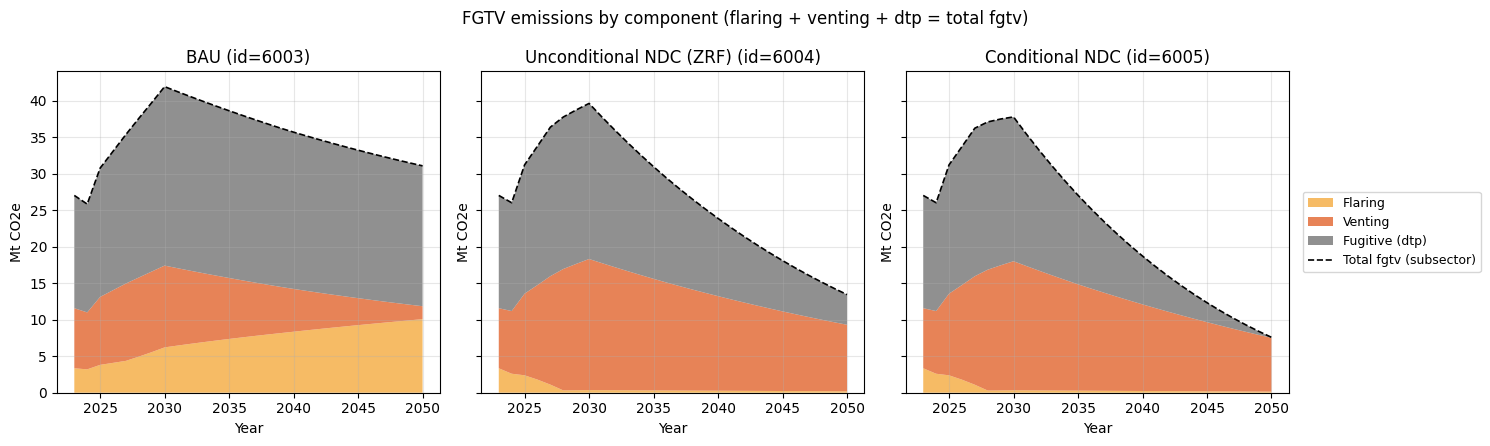

In [69]:
STRATEGY_NAMES = {6003: 'BAU', 6004: 'Unconditional NDC (ZRF)', 6005: 'Conditional NDC'}
strategies_all = sorted(comp.strategy_id.unique())
fig, axes = plt.subplots(1, len(strategies_all), figsize=(5.0*len(strategies_all), 4.5), sharey=True)
if len(strategies_all) == 1: axes = [axes]
comp_colors = {'flaring': '#f5b04a', 'venting': '#e36d3a', 'dtp': '#7d7d7d'}
for ax, sid in zip(axes, strategies_all):
    sub = comp[comp.strategy_id == sid].set_index('year').sort_index()
    ax.stackplot(sub.index, sub['flaring'], sub['venting'], sub['dtp'],
                 labels=['Flaring','Venting','Fugitive (dtp)'],
                 colors=[comp_colors['flaring'], comp_colors['venting'], comp_colors['dtp']], alpha=0.85)
    ax.plot(sub.index, sub['total_subsector'], 'k--', lw=1.2, label='Total fgtv (subsector)')
    ax.set_title(f"{STRATEGY_NAMES.get(sid, sid)} (id={sid})")
    ax.set_xlabel('Year'); ax.set_ylabel('Mt CO2e'); ax.grid(alpha=0.3)
axes[-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
fig.suptitle('FGTV emissions by component (flaring + venting + dtp = total fgtv)')
plt.tight_layout(); plt.show()

## Chart 1 — Oil production + flaring volumes

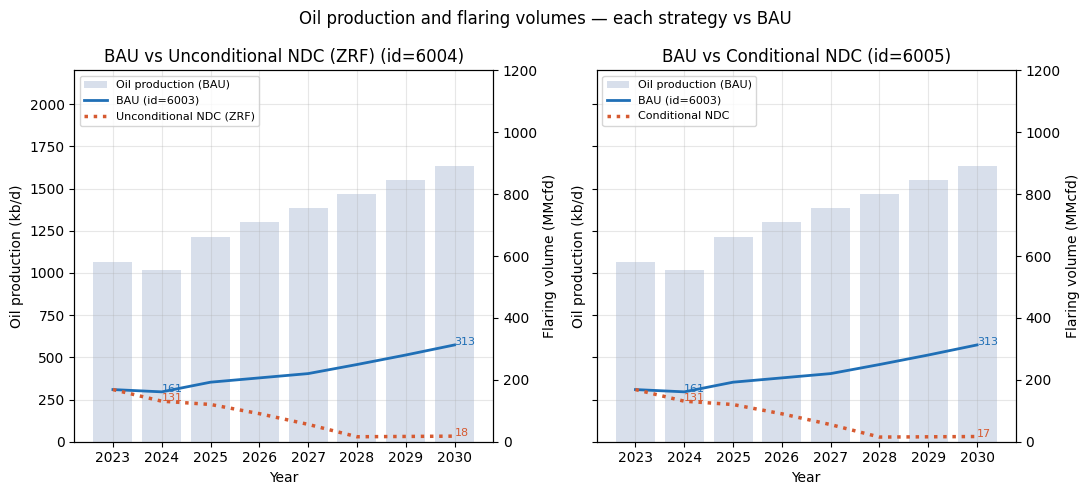

In [70]:
STRATEGY_NAMES = {6003: 'BAU', 6004: 'Unconditional NDC (ZRF)', 6005: 'Conditional NDC'}
yrs = list(range(2023, 2031))
compare = [s for s in sorted(agg.strategy_id.unique()) if s != BAU_STRATEGY]
bau = agg[agg.strategy_id == BAU_STRATEGY].set_index('year').sort_index()
fig, axes = plt.subplots(1, len(compare), figsize=(5.5*len(compare), 5), sharey=True)
if len(compare) == 1: axes = [axes]
for ax1, sid in zip(axes, compare):
    sub = agg[agg.strategy_id == sid].set_index('year').sort_index()
    ax1.bar(yrs, bau.loc[yrs, 'oil_kbd'], color='#cfd8e6', alpha=0.8, label='Oil production (BAU)')
    ax1.set_ylim(0, 2200); ax1.set_ylabel('Oil production (kb/d)'); ax1.set_xlabel('Year'); ax1.grid(alpha=0.3)
    ax2 = ax1.twinx()
    ax2.plot(yrs, bau.loc[yrs, 'flared_mmcfd'], '-', color='#1f6fb6', lw=2, label=f'BAU (id={BAU_STRATEGY})')
    ax2.plot(yrs, sub.loc[yrs, 'flared_mmcfd'], ':', color='#d65a31', lw=2.5, label=f"{STRATEGY_NAMES.get(sid, sid)}")
    ax2.set_ylim(0, 1200); ax2.set_ylabel('Flaring volume (MMcfd)')
    ax1.set_title(f"BAU vs {STRATEGY_NAMES.get(sid, sid)} (id={sid})")
    for y in [2024, 2030]:
        ax2.annotate(f"{bau.loc[y,'flared_mmcfd']:.0f}", (y, bau.loc[y,'flared_mmcfd']), fontsize=8, color='#1f6fb6')
        ax2.annotate(f"{sub.loc[y,'flared_mmcfd']:.0f}", (y, sub.loc[y,'flared_mmcfd']), fontsize=8, color='#d65a31')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=8)
fig.suptitle('Oil production and flaring volumes — each strategy vs BAU')
plt.tight_layout(); plt.show()

## Chart 2 — Flaring emissions and intensity

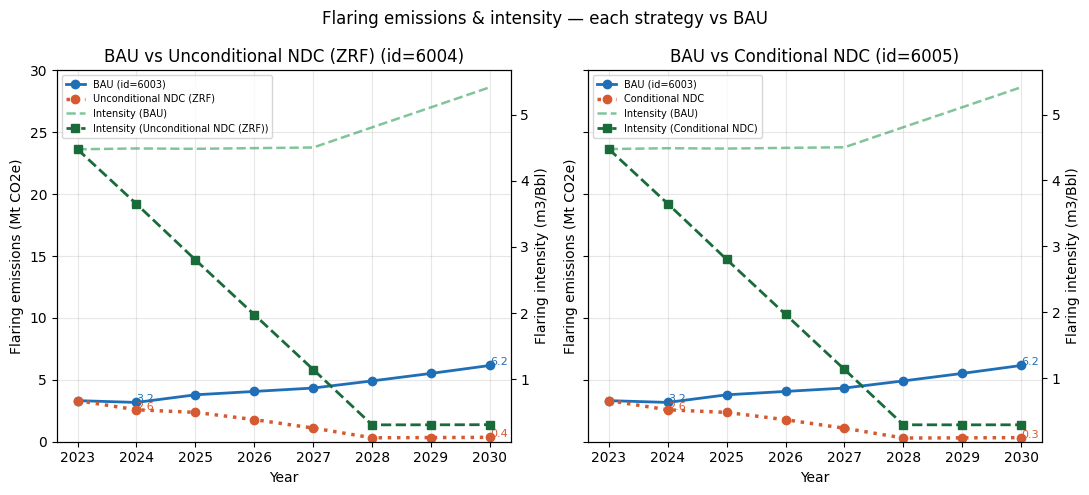

In [71]:
fig, axes = plt.subplots(1, len(compare), figsize=(5.5*len(compare), 5), sharey=True)
if len(compare) == 1: axes = [axes]
ymax_e = max(30, agg.flar_emis_mt_co2e.max()*1.1)
for ax1, sid in zip(axes, compare):
    sub = agg[agg.strategy_id == sid].set_index('year').sort_index()
    ax1.plot(yrs, bau.loc[yrs, 'flar_emis_mt_co2e'], '-o', color='#1f6fb6', lw=2, label=f'BAU (id={BAU_STRATEGY})')
    ax1.plot(yrs, sub.loc[yrs, 'flar_emis_mt_co2e'], ':o', color='#d65a31', lw=2.5, label=f"{STRATEGY_NAMES.get(sid, sid)}")
    ax1.set_ylabel('Flaring emissions (Mt CO2e)'); ax1.set_xlabel('Year'); ax1.grid(alpha=0.3); ax1.set_ylim(0, ymax_e)
    ax2 = ax1.twinx()
    ax2.plot(yrs, bau.loc[yrs, 'flar_intensity_m3_per_bbl'], '--', color='#2e9e57', lw=1.8, alpha=0.6, label='Intensity (BAU)')
    ax2.plot(yrs, sub.loc[yrs, 'flar_intensity_m3_per_bbl'], '--s', color='#1a6b3a', lw=2, label=f'Intensity ({STRATEGY_NAMES.get(sid, sid)})')
    ax2.set_ylabel('Flaring intensity (m3/Bbl)')
    ax1.set_title(f"BAU vs {STRATEGY_NAMES.get(sid, sid)} (id={sid})")
    for y in [2024, 2030]:
        ax1.annotate(f"{bau.loc[y,'flar_emis_mt_co2e']:.1f}", (y, bau.loc[y,'flar_emis_mt_co2e']), fontsize=8, color='#1f6fb6')
        ax1.annotate(f"{sub.loc[y,'flar_emis_mt_co2e']:.1f}", (y, sub.loc[y,'flar_emis_mt_co2e']), fontsize=8, color='#d65a31')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=7)
fig.suptitle('Flaring emissions & intensity — each strategy vs BAU')
plt.tight_layout(); plt.show()

## Chart 3 — CH4 emissions by emission type, 2024

SSP emission types: Flared (`fgtv_flaring`), Vented (`fgtv_venting`), Fugitive (`fgtv_dtp`).
Facility-type breakdown (Onshore oil / Offshore oil / Onshore gas / Offshore gas / Pipelines+LNG / Abandoned / Satellite) does **not** exist natively in SSP — we apply IEA Methane Tracker 2024 shares as a post-hoc split.

IEA shares (per CCD doc text, B.2): onshore oil 90.9%, offshore oil 2.6%, onshore gas 1.7%; remainder split across other facility types.

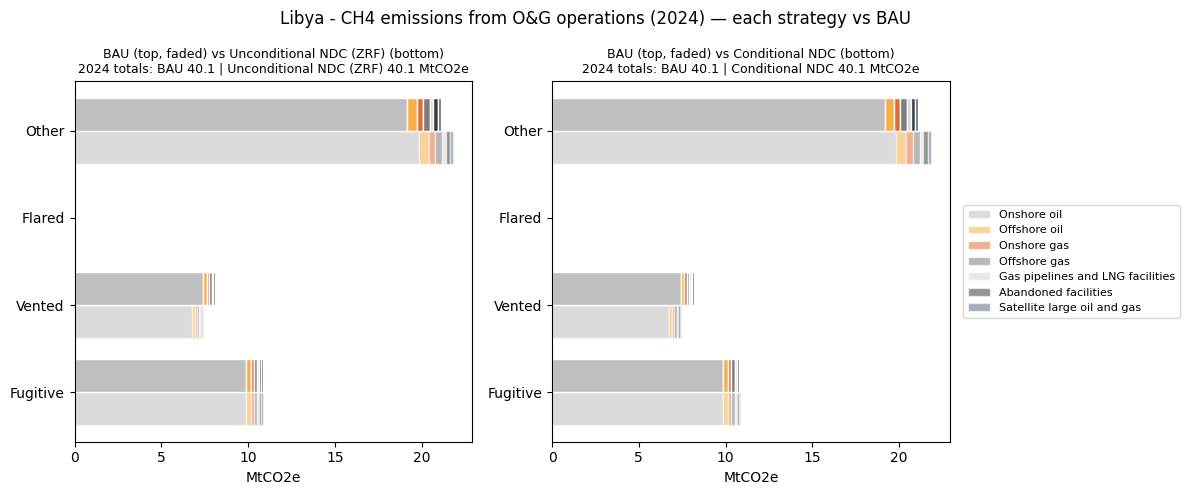

{6003: {'Flared': np.float64(0.009661123643999018),
  'Vented': np.float64(7.4105789955661265),
  'Fugitive': np.float64(10.848664054675616),
  'Other': np.float64(21.831095826114257)},
 np.int64(6004): {'Flared': np.float64(0.007860451350578968),
  'Vented': np.float64(8.156128154424561),
  'Fugitive': np.float64(10.848664053098876),
  'Other': np.float64(21.087347341125984)},
 np.int64(6005): {'Flared': np.float64(0.007856112376780192),
  'Vented': np.float64(8.15792465563506),
  'Fugitive': np.float64(10.848664046778955),
  'Other': np.float64(21.085555185209206)}}

In [72]:
IEA_FACILITY_SHARES = {
    'Onshore oil': 0.909,
    'Offshore oil': 0.026,
    'Onshore gas': 0.017,
    'Offshore gas': 0.018,
    'Gas pipelines and LNG facilities': 0.010,
    'Abandoned facilities': 0.012,
    'Satellite large oil and gas': 0.008,
}
assert abs(sum(IEA_FACILITY_SHARES.values()) - 1.0) < 0.01

etypes = ['Other', 'Flared', 'Vented', 'Fugitive']
facilities = list(IEA_FACILITY_SHARES.keys())
colors = ['#bfbfbf','#f5b04a','#e36d3a','#7d7d7d','#d6d6d6','#3a3a3a','#5a6b8a']
anchor = 2024

def ch4_breakdown(sid):
    row = df[(df.strategy_id == sid) & (df.year == anchor)].iloc[0]
    out = {
        'Flared': sum(row[c] for c in FGTV_FLAR_CH4),
        'Vented': sum(row[c] for c in FGTV_VENT_CH4),
        'Fugitive': sum(row[c] for c in FGTV_DTP_CH4),
    }
    out['Other'] = max(40.1 - sum(out.values()), 0)
    return out

ch4_bau = ch4_breakdown(BAU_STRATEGY)
all_ch4 = {BAU_STRATEGY: ch4_bau}
fig, axes = plt.subplots(1, len(compare), figsize=(6.0*len(compare), 5), sharex=True)
if len(compare) == 1: axes = [axes]
y_pos = np.arange(len(etypes))
h = 0.38
for ax, sid in zip(axes, compare):
    ch4_s = ch4_breakdown(sid)
    all_ch4[sid] = ch4_s
    # BAU bars (top)
    for j, et in enumerate(etypes):
        left = 0
        for fac, col in zip(facilities, colors):
            w = ch4_bau[et] * IEA_FACILITY_SHARES[fac]
            ax.barh(j + h/2, w, height=h, left=left, color=col, edgecolor='white',
                    label=fac if (j == 0 and ax is axes[-1]) else None, alpha=0.55)
            left += w
    # Strategy bars (bottom)
    for j, et in enumerate(etypes):
        left = 0
        for fac, col in zip(facilities, colors):
            w = ch4_s[et] * IEA_FACILITY_SHARES[fac]
            ax.barh(j - h/2, w, height=h, left=left, color=col, edgecolor='white')
            left += w
    ax.set_yticks(y_pos); ax.set_yticklabels(etypes)
    ax.set_title(f"BAU (top, faded) vs {STRATEGY_NAMES.get(sid, sid)} (bottom)\n2024 totals: BAU {sum(ch4_bau.values()):.1f} | {STRATEGY_NAMES.get(sid, sid)} {sum(ch4_s.values()):.1f} MtCO2e", fontsize=9)
    ax.set_xlabel('MtCO2e'); ax.invert_yaxis()
axes[-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
fig.suptitle('Libya - CH4 emissions from O&G operations (2024) — each strategy vs BAU')
plt.tight_layout(); plt.show()
ch4_by_type = ch4_bau   # keep BAU dict for downstream Tableau export
all_ch4

## Export base for Tableau
Long-format CSV with columns: `year`, `strategy_id`, `strategy_name`, `metric`, `facility_type`, `value`, `units`. Saved to `ssp_modeling/tableau/data/oilgas_ccd_charts_libya.csv`.

In [73]:
STRATEGY_NAMES = {6003: 'BAU', 6004: 'Unconditional NDC (ZRF)', 6005: 'Conditional NDC'}

rows = []
# Time-series metrics (chart 1 & 2): one row per (year, strategy, metric)
ts_cols = {
    'oil_kbd': 'kb/d',
    'flared_mmcfd': 'MMcfd',
    'flared_bcm': 'Bcm/yr',
    'flar_emis_mt_co2e': 'Mt CO2e',
    'vent_ch4_mt_co2e': 'Mt CO2e',
    'dtp_ch4_mt_co2e': 'Mt CO2e',
    'flar_intensity_m3_per_bbl': 'm3/Bbl',
    'prod_enfu_fuel_crude_pj': 'PJ/yr',
    'prod_enfu_fuel_natural_gas_pj': 'PJ/yr',
}
for sid, sub in agg.groupby('strategy_id'):
    for _, r in sub.iterrows():
        for metric, units in ts_cols.items():
            rows.append({
                'year': int(r['year']),
                'strategy_id': int(sid),
                'strategy_name': STRATEGY_NAMES.get(int(sid), str(sid)),
                'chart': 'time_series',
                'metric': metric,
                'facility_type': 'All',
                'value': float(r[metric]),
                'units': units,
            })

# Chart 3: CH4 by emission type x facility for the anchor year (2024) for BAU
anchor = 2024
for et, total in ch4_by_type.items():
    for fac, share in IEA_FACILITY_SHARES.items():
        rows.append({
            'year': anchor,
            'strategy_id': BAU_STRATEGY,
            'strategy_name': STRATEGY_NAMES.get(BAU_STRATEGY, str(BAU_STRATEGY)),
            'chart': 'ch4_breakdown',
            'metric': f'CH4_{et}',
            'facility_type': fac,
            'value': float(total * share),
            'units': 'Mt CO2e',
        })

tab = pd.DataFrame(rows)
out_path = Path('/Users/fabianfuentes/git/ssp_libya/ssp_modeling/tableau/data/oilgas_ccd_charts_libya.csv')
out_path.parent.mkdir(parents=True, exist_ok=True)
tab.to_csv(out_path, index=False)
print(f'Wrote {len(tab)} rows to {out_path}')
tab.head()

Wrote 784 rows to /Users/fabianfuentes/git/ssp_libya/ssp_modeling/tableau/data/oilgas_ccd_charts_libya.csv


,year,strategy_id,strategy_name,chart,metric,facility_type,value,units
0,2023,6003,BAU,time_series,oil_kbd,All,1065.842018,kb/d
1,2023,6003,BAU,time_series,flared_mmcfd,All,168.518357,MMcfd
2,2023,6003,BAU,time_series,flared_bcm,All,1.741745,Bcm/yr
3,2023,6003,BAU,time_series,flar_emis_mt_co2e,All,3.319417,Mt CO2e
4,2023,6003,BAU,time_series,vent_ch4_mt_co2e,All,7.777551,Mt CO2e
